## Calving series methodology for Jakobshavn Isbrae ##

This notebook is the first copy of deriving a calving time series for glacier Jakobshavn Isbrae in Greenland. 

This notebook develops a __calving time series__ using:
1. satellite-derived terminus positions
2. surface velocity near the terminnus, and 
3. different metrics of terminus change

Where __length change__, is measured along the centerline, a common proxy for average glacier retreat; and __area change__ is across the full width of the glacier, capturing along-terminus variability and asymmetric calving behavior.



#### 1. Set up notebook and load in data ####

In [1]:
# Notebook set up: import dependencies and packages
# Run this on greenlandMapping 
%load_ext autoreload
%autoreload 2
import os
import dask
import panel
import pandas as pd
import matplotlib.pyplot as plt
import nisardev as nisar
import grimpfunc as grimp
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import geopandas as gpd
import glob
import shapely
import rasterio
import geopandas as gpd
from shapely.geometry import LineString
from dask.diagnostics import ProgressBar
import matplotlib.ticker as mticker
from shapely.ops import linemerge, unary_union


In [2]:
#paths
centreline_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/flowlines/glacier0001_iter03.shp"
centerline_extended_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/flowlines/jakobshavn_centreline_ss.shp"
terminus_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/data/MEaSUREs_0781/collated/JakbobshavnIsbraeTerminus.shp"
velocity_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/data/MEaSUREs_0766/JakobshavnIsbraeVelocitySeriesNew.nc"

#read in velocity 
velocity = xr.open_dataset(velocity_path)

#read in centreline + make sure coordinate system = EPSG:3413
centerline = gpd.read_file(centreline_path)
centerline = centerline.to_crs("EPSG:3413")
centerline_shape = centerline.geometry.iloc[0]

# read in extended centreline and make sure coordinate system = EPSG:3413
centerline_extended = gpd.read_file(centerline_extended_path)
centerline_extended = centerline_extended.to_crs("EPSG:3413")

# merge extended centreline into 1 geometry
c_merged = linemerge(unary_union(centerline_extended.geometry))
centerline_extended = gpd.GeoDataFrame(geometry=[c_merged], crs=centerline_extended.crs)
centerline_extended_shape = centerline_extended.geometry.iloc[0]


#sanity check for geospatial alignment
print(centerline.crs)
print(centerline_extended.crs)

#read in terminus
terminus = gpd.read_file(terminus_path)
terminus = terminus.to_crs("EPSG:3413")

#sanity check for geospatial alignment
print(terminus.crs)

EPSG:3413
EPSG:3413
EPSG:3413


In [3]:
#cleaning
terminus = terminus.rename(columns={"SourceDate": "Date", "Quality_Fl" : "Flag"}) #rename for simplicity
terminus["Date"] = pd.to_datetime(terminus["Date"]) #make sure it is in datetime 
terminus = terminus.sort_values(by = 'Date')
terminus.drop_duplicates(subset = ['Glacier_ID', 'Date'], keep = 'first') #drop duplicates

,Image_ID,Image_Tile,Date,Flag,Glacier_ID,geometry
3,SEN1_NSIDC_0723_V2_20150101_20150112,S1A_090_004012,2015-01-03,0,3,"LINESTRING (-188606.112 -2265922.891, -188399...."
4,SEN1_NSIDC_0723_V2_20150113_20150124,S1A_090_004187,2015-01-15,1,3,"LINESTRING (-188634.464 -2265910.404, -188629...."
5,SEN1_NSIDC_0723_V2_20150125_20150205,S1A_090_004362,2015-01-27,1,3,"LINESTRING (-186068.771 -2276605.242, -185814...."
6,SEN1_NSIDC_0723_V2_20150206_20150217,S1A_090_004537,2015-02-08,0,3,"LINESTRING (-184745.971 -2277111.477, -184132...."
17,SEN1_NSIDC_0723_V4_20150218_20150301,S1A_090_004712,2015-02-20,0,3,"LINESTRING (-185068.764 -2276846.893, -184507...."
...,...,...,...,...,...,...
351,SEN1_NSIDC_0723_V4_20211125_20211130,S1A_090_040762,2021-11-27,0,3,"LINESTRING (-185111.097 -2276688.143, -184878...."
352,SEN1_NSIDC_0723_V4_20211201_20211206,S1B_090_029866,2021-12-03,1,3,"LINESTRING (-185164.014 -2276666.976, -184867...."
353,SEN1_NSIDC_0723_V4_20211207_20211212,S1A_090_040937,2021-12-09,1,3,"LINESTRING (-184931.18 -2276910.393, -184380.8..."
354,SEN1_NSIDC_0723_V4_20211213_20211218,S1B_090_030041,2021-12-15,1,3,"LINESTRING (-184793.596 -2276973.893, -184497...."


##### 2. Data visualisation / spatial verification ####
*What does the velocity data look like? Are the centreline and terminus geometries aligned?* 


In these cells I want to inspect the spatial coverage of the valid velcoity observations across all the data, this will be helpful in seeing how much valid velocity data I do have for my time series. 

In [4]:
#plotting configurations
# colors
dark_blue = "#1f3a5f"
light_blue = "#6baed6"

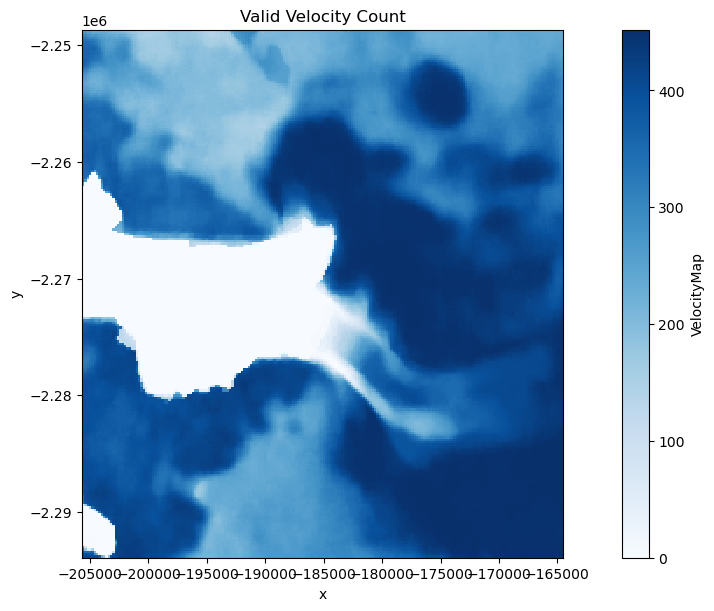

In [5]:
#preparing velocity data for plotting
x_vals = velocity["x"].values
y_vals = velocity["y"].values

vel_band = velocity["VelocityMap"].isel(band=2).assign_coords(
    x=("x", x_vals),
    y=("y", y_vals),
)
vel_times = pd.to_datetime(vel_band["time"].values)

valid_count = vel_band.count(dim="time")  #points with "valid" non NaN values

fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

#Figure 1: Valid velocity count across all time steps
valid_count.plot(
    ax=ax,
    x="x",
    y="y",
    cmap = "Blues", 
    add_colorbar=True,
)
ax.set_title("Valid Velocity Count")
ax.set_aspect("equal")


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


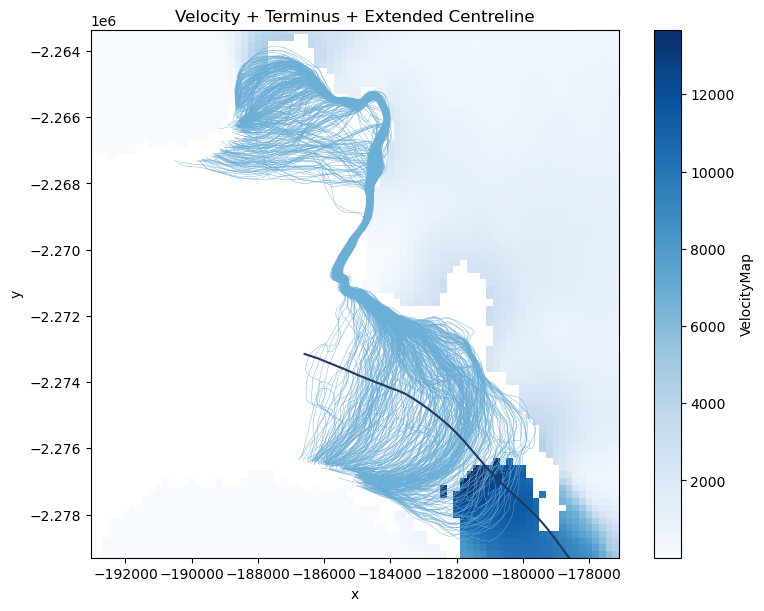

In [6]:
# Plot a representative velocity slice together with terminus geometries and the EXTENDED centreline

# preparing velocity data for plotting
x_vals = velocity["x"].values
y_vals = velocity["y"].values

vel_band = velocity["VelocityMap"].isel(band=2).assign_coords(
    x=("x", x_vals),
    y=("y", y_vals),
)
vel_times = pd.to_datetime(vel_band["time"].values)

valid_count = vel_band.count(dim="time")  # points with valid non-NaN values

sampletime = 300
vel_slice = velocity["VelocityMap"].isel(band=2, time=sampletime)

# preparing centreline for plotting
centreline_gs_ext = gpd.GeoSeries([centerline_extended_shape], crs=terminus.crs)

fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

# 1: velocity with terminus and extended centreline
vel_slice.plot(
    ax=ax,
    x="x",
    y="y",
    cmap="Blues",
    add_colorbar=True,
)

terminus.plot(
    ax=ax,
    facecolor="none",
    edgecolor=light_blue,
    linewidth=0.3,
)

centreline_gs_ext.plot(
    ax=ax,
    color=dark_blue,
    linewidth=1.5,
)

ax.set_title("Velocity + Terminus + Extended Centreline")

# zoom in to see intersection better
xmin, ymin, xmax, ymax = terminus.total_bounds
zoom = 500

ax.set_xlim(xmin - zoom, xmax + zoom)
ax.set_ylim(ymin - zoom, ymax + zoom)
ax.set_box_aspect(1)

plt.show()

velocity: 2017-09-25 12:00:00
terminus: 2017-09-25 00:00:00
velocity: 2020-10-21 12:00:00
terminus: 2020-10-21 00:00:00


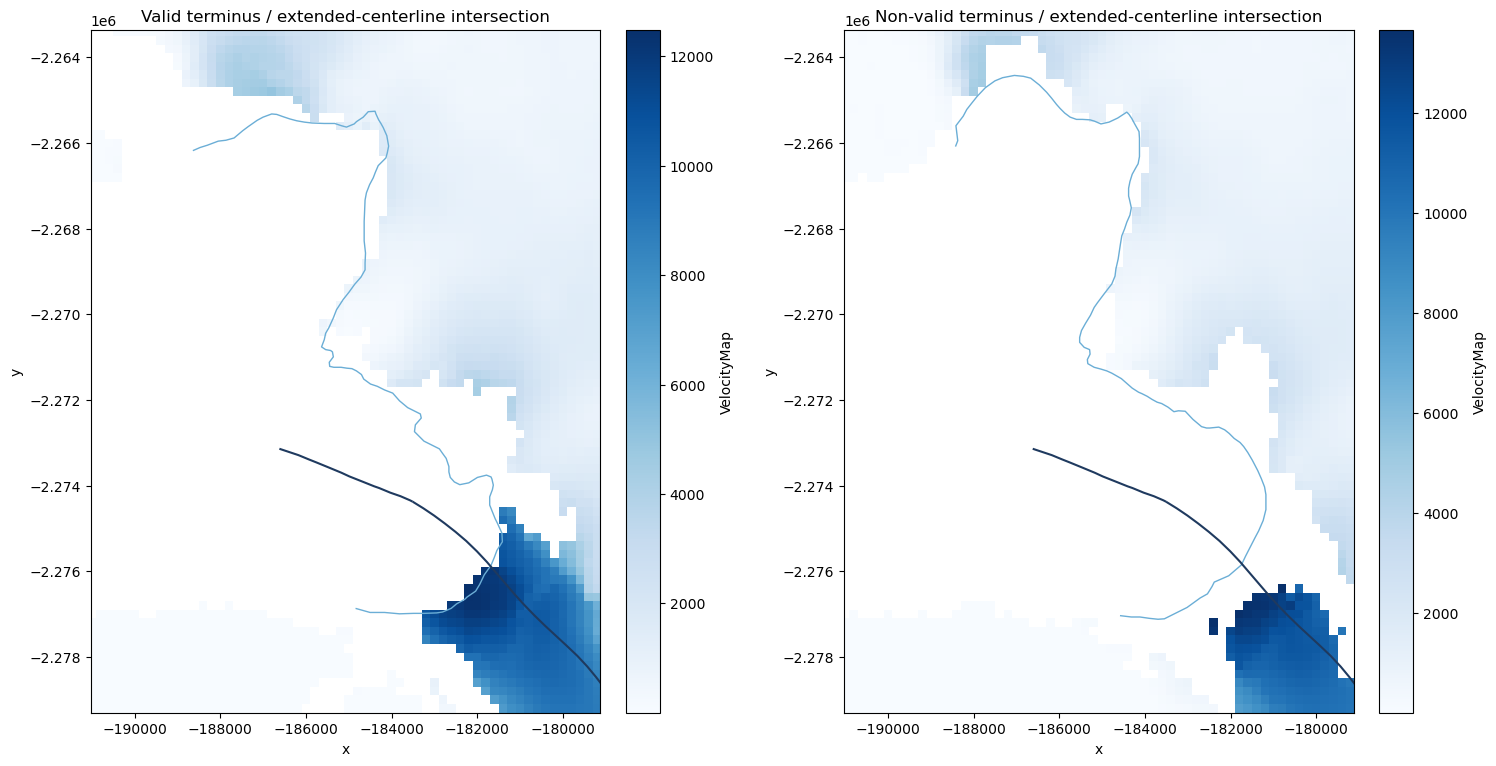

In [7]:
# visualising velocity, terminus and EXTENDED centerline on one with a VALID intersection value
# velocity: 2017-10-01 12:00:00
# terminus: 2017-10-01 00:00:00

sampletime1 = 113

vel_time = velocity["time"].isel(time=sampletime1).values
nearest_time = (terminus["Date"] - vel_time).abs().idxmin()  # nearest terminus date to velocity time
term_time = terminus.loc[[nearest_time]]

vel_slice = velocity["VelocityMap"].isel(band=2, time=sampletime1)

t_vel = pd.to_datetime(vel_time)
t_term = term_time["Date"].iloc[0]
print("velocity:", t_vel)
print("terminus:", t_term)

vel_slice = vel_slice.assign_coords(
    x=("x", x_vals),
    y=("y", y_vals),
)

nrow, ncol = (1, 2)

fig, ax = plt.subplots(
    figsize=(15, 15),
    layout="compressed",
    nrows=nrow,
    ncols=ncol,
)

vel_slice.plot(
    ax=ax[0],
    x="x",
    y="y",
    cmap="Blues",
    add_colorbar=True,
)

term_time.plot(
    ax=ax[0],
    facecolor="none",
    edgecolor=light_blue,
    linewidth=1,
)

centreline_gs_ext = gpd.GeoSeries(
    [centerline_extended_shape],
    crs=terminus.crs if hasattr(terminus, "crs") else None
)
centreline_gs_ext.plot(
    ax=ax[0],
    color=dark_blue,
    linewidth=1.5,
)

# visualising velocity, terminus and EXTENDED centerline on one with a NON-VALID intersection value
sampletime2 = 300

vel_time = velocity["time"].isel(time=sampletime2).values
nearest_time = (terminus["Date"] - vel_time).abs().idxmin()
term_time = terminus.loc[[nearest_time]]

vel_slice = velocity["VelocityMap"].isel(band=2, time=sampletime2)

# check: are these the same day / near?
t_vel = pd.to_datetime(vel_time)
t_term = term_time["Date"].iloc[0]
print("velocity:", t_vel)
print("terminus:", t_term)

vel_slice = vel_slice.assign_coords(
    x=("x", x_vals),
    y=("y", y_vals),
)

vel_slice.plot(
    ax=ax[1],
    x="x",
    y="y",
    cmap="Blues",
    add_colorbar=True,
)

term_time.plot(
    ax=ax[1],
    facecolor="none",
    edgecolor=light_blue,
    linewidth=1,
)

centreline_gs_ext.plot(
    ax=ax[1],
    color=dark_blue,
    linewidth=1.5,
)

# zoom in order to see intersection better
xmin, ymin, xmax, ymax = terminus.total_bounds
zoom = 500

for a in ax:
    a.set_xlim(xmin - zoom, xmax + zoom)
    a.set_ylim(ymin - zoom, ymax + zoom)

ax[0].set_title("Valid terminus / extended-centerline intersection")
ax[1].set_title("Non-valid terminus / extended-centerline intersection")

plt.show()

### Step 1: Finding centreline and terminus intersection 

In [8]:
# finding the intersection between the centerline and the terminus
def intersection(centreline, terminus_line):
    intersect = centreline.intersection(terminus_line)

    if intersect.is_empty:
        return None
    
    if intersect.geom_type == "MultiPoint": #if there is more than one intersect put the point closes to the centre of the terminus line
        return min(intersect.geoms, key = lambda p: p.distance(terminus_line.centroid))
    
    return intersect
 
pts = []
for i in range(len(terminus)):
    terminus_line = terminus.geometry.iloc[i]
    pt = intersection(centerline_extended_shape, terminus_line) #geometric intersection between centerline_shape and terminus_line 
    pts.append(pt)

terminus["intersect_points"] = pts

#check to see how many are NaN (i.e. no valid intersection)
none_vals = terminus["intersect_points"].isna().sum()
print(f"Number of NaN intersection points: {none_vals}")

#check to see how many are non NaN (i.e. valid intersection)
valid_vals = terminus["intersect_points"].notna().sum()
print(f"Number of valid intersection points: {valid_vals} out of {len(terminus)}")


Number of NaN intersection points: 0
Number of valid intersection points: 357 out of 357


### Step 2: Sample velocity at X m away from the intersection
- Using a consistent simple velocity extraction method
- As a comparison add a list that is velocity at intersection

In [9]:
upstream_m = 1500

vel_at_intersection = []
vel_up_centreline = []

for i in range(len(terminus)):
    pt = terminus["intersect_points"].iloc[i]
    t_term = pd.to_datetime(terminus["Date"].iloc[i])

    if pt is None:
        vel_at_intersection.append(np.nan)
        vel_up_centreline.append(np.nan)
        continue

    vel_slice = vel_band.sel(time=t_term, method="nearest")

    # velocity at intersection
    v0 = vel_slice.sel(x=pt.x, y=pt.y, method="nearest").values
    vel_at_intersection.append(float(v0) if np.isfinite(v0) else np.nan)

    # velocity upstream along the same unextended centreline
    d0 = centerline_extended_shape.project(pt)
    d1 = d0 + upstream_m

    # if upstream point would go past the end of the unextended centreline, return NaN
    if d1 > centerline_extended_shape.length:
        vel_up_centreline.append(np.nan)
        continue

    p1 = centerline_extended_shape.interpolate(float(d1))
    v1 = vel_slice.sel(x=p1.x, y=p1.y, method="nearest").values
    vel_up_centreline.append(float(v1) if np.isfinite(v1) else np.nan)

terminus["vel_at_intersection"] = vel_at_intersection
terminus["vel_up_centreline"] = vel_up_centreline

In [10]:
# -- Optional Smoothing and interpolation of velocity upstream of the centerline intersection --
#smoothed and interpolated velocity upstream of the centerline intersection
#window = "12D"  # 12-day rolling window
#smoothing = terminus.set_index("Date")["vel_up_centreline"].sort_index()
#smoothed = smoothing.rolling(window=window, min_periods=1, center=True).mean()
#smoothed_interp = smoothed.interpolate(method="time", limit=5)
#terminus["vel_up_smoothed_interp"] = smoothed_interp.reindex(terminus["Date"]).to_numpy()

print(f"Number of valid values in vel_at_intersection: {terminus['vel_at_intersection'].notna().sum()} out of {len(terminus)}")
print(f"Number of valid values in vel_up_centreline: {terminus['vel_up_centreline'].notna().sum()} out of {len(terminus)}")
#print(f"Number of valid values in vel_up_smoothed_interp: {terminus['vel_up_smoothed_interp'].notna().sum()} out of {len(terminus)}")

Number of valid values in vel_at_intersection: 52 out of 357
Number of valid values in vel_up_centreline: 188 out of 357


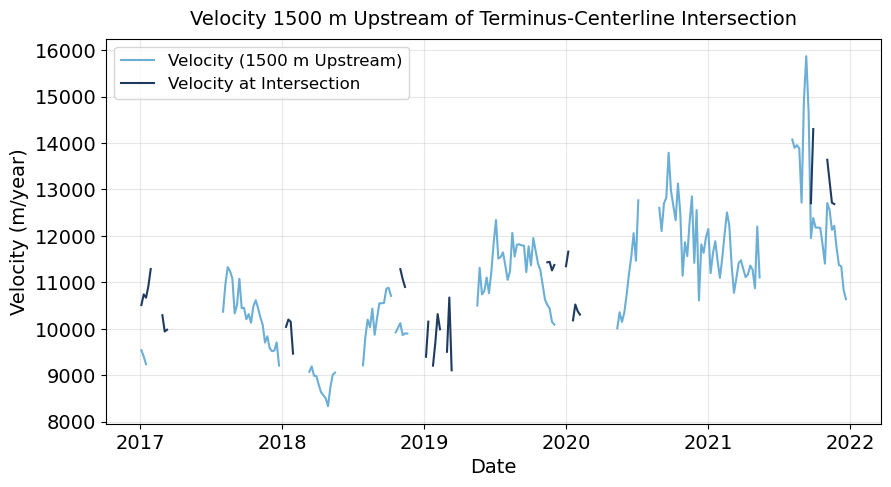

In [11]:
#cut to 2017
velocity_plot = terminus[terminus["Date"] >= "2017"].copy()

plt.figure(figsize=(10, 5))
plt.plot(velocity_plot["Date"]  , velocity_plot["vel_up_centreline"], label="Velocity (1500 m Upstream)", color= light_blue)
plt.plot(velocity_plot["Date"]  , velocity_plot["vel_at_intersection"], label="Velocity at Intersection", color= dark_blue)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Velocity (m/year)", fontsize=14)
plt.title("Velocity 1500 m Upstream of Terminus-Centerline Intersection", fontsize = 14, pad = 10)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout
plt.show()


For each terminus position:
1. Use the centerline-terminus intersection point
2. Get the length of the upstream segment 

This is Taryn's code - slightly modified

In [12]:
type(terminus)

geopandas.geodataframe.GeoDataFrame

In [13]:
def get_centerline_length(terminus, centerline):
    # ensure terminus terminus data type
    if type(terminus) is LineString:
        pass
    if type(terminus) is pd.Series:
        pt = terminus["intersect_points"]
    elif type(terminus) is gpd.GeoSeries:
        pt = terminus["intersect_points"].item()
    else:
        pt = terminus

    # ensure centerline data type
    if type(centerline) is LineString:
        pass
    elif type(centerline) is pd.Series:
        centerline = centerline.geometry
    elif type(centerline) is gpd.GeoSeries:
        centerline = centerline.item()

    # if no valid intersection point, return nan
    if pt is None:
        return np.nan

    try:
        # distance from start of centerline to intersection point
        d = centerline.project(pt)

        # upstream length = total centerline length minus projected distance
        centerline_length = centerline.length - d
    except:
        centerline_length = np.nan

    return centerline_length

# calculate glacier length at centerline for each terminus
terminus["Centerline_Length"] = terminus.apply(get_centerline_length, axis=1, centerline=centerline_shape)
terminus = terminus[terminus["Centerline_Length"].notna()].copy()

# use the first valid terminus as a baseline
terminus["Centerline_Length"] -= terminus["Centerline_Length"].iloc[0]

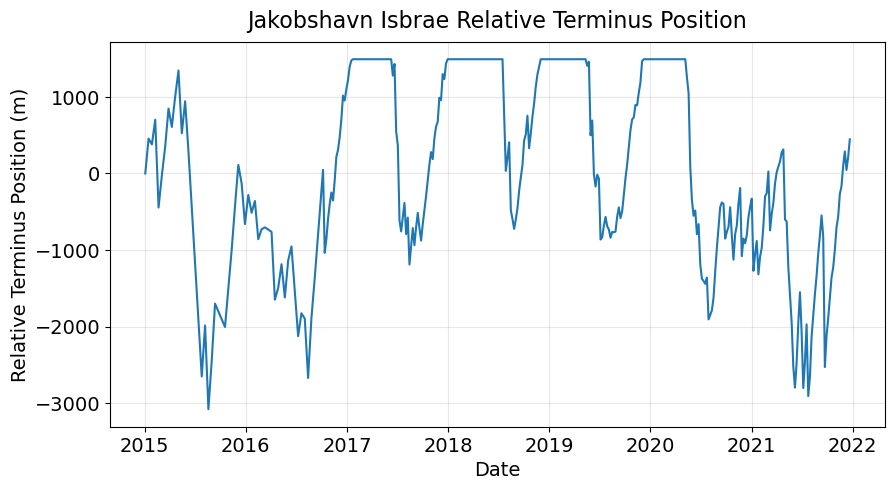

In [14]:
plt.figure(figsize=(10,5))
plt.plot(terminus["Date"], terminus["Centerline_Length"])
plt.title("Jakobshavn Isbrae Relative Terminus Position", fontsize= 16, pad = 10)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Relative Terminus Position (m)", fontsize=14)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.grid(True, alpha=0.3)
plt.tight_layout
plt.show()


In [15]:
# observed terminus position
terminus["L"] = terminus["Centerline_Length"]

# time step
terminus["dt_days"] = terminus["Date"].diff().dt.days
terminus["dt_years"] = terminus["dt_days"] / 365.25

# observed change in terminus position
terminus["dL"] = terminus["L"].diff()
terminus["dLdt"] = terminus["dL"] / terminus["dt_years"]

# expected position at t based on previous position + previous velocity * elapsed time
terminus["L_expected"] = (terminus["L"].shift(1) + terminus["vel_up_centreline"].shift(1) * terminus["dt_years"]
)

# difference between expected and observed position
terminus["expected_minus_observed"] = terminus["L_expected"] - terminus["L"]

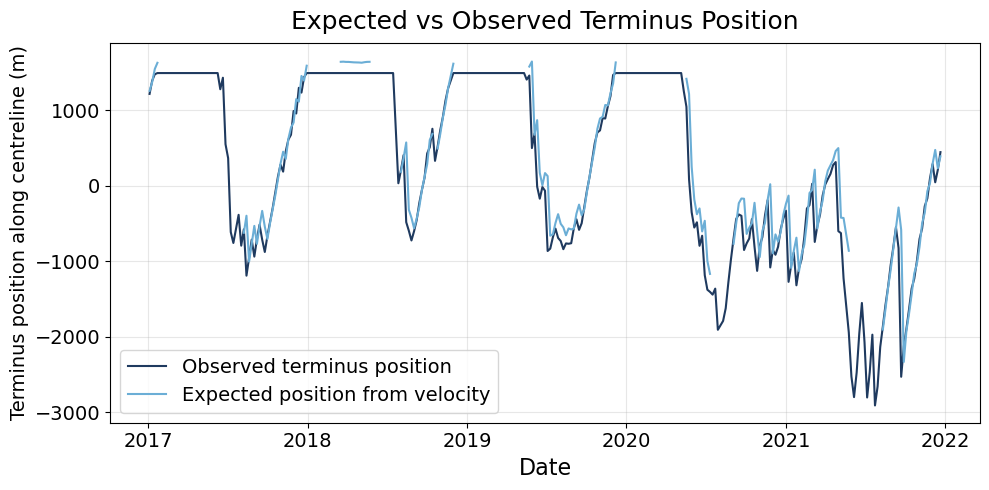

In [16]:
# cut to 2017
terminus_plot = terminus[terminus["Date"] >= "2017"].copy()

plt.figure(figsize=(10, 5))
plt.plot(
    terminus_plot["Date"],
    terminus_plot["L"],
    color=dark_blue,
    label="Observed terminus position"
)
plt.plot(
    terminus_plot["Date"],
    terminus_plot["L_expected"],
    color=light_blue,
    label="Expected position from velocity"
)

plt.xlabel("Date", fontsize=16)
plt.ylabel("Terminus position along centreline (m)", fontsize=14)
plt.title("Expected vs Observed Terminus Position", fontsize=18, pad=10)
plt.xticks(size=14)
plt.yticks(size=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

Calving events are positive:
- dLdt > 0 means length is increasing with time - i.e., advance 
- dLdT < 0 means length is decreasing with time - i.e., retreat
    - according to plot dLdt is primarily negative
- vel > 0 flowing towards terminus 

So calving = positve value - negative value, therefore, calving is positive 

In [17]:
terminus["calving"] = terminus["vel_up_centreline"] - terminus["dLdt"]
terminus["calving_magnitude"] = terminus["calving"]/365.25

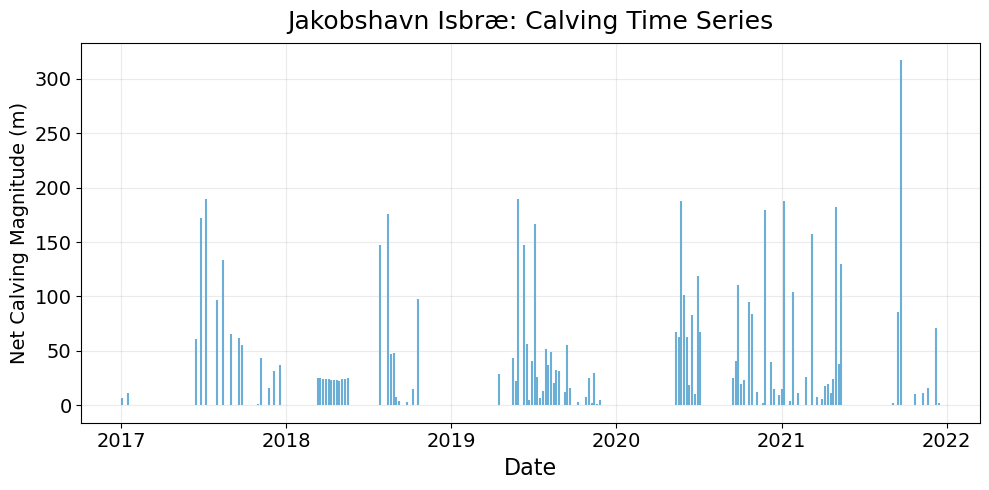

In [18]:
# cut to 2017
terminus_plot = terminus[terminus["Date"] >= "2017"].copy()

# mask negative values
terminus_plot["calving_positive"] = terminus_plot["calving_magnitude"].where(terminus_plot["calving_magnitude"] > 0)


plt.figure(figsize=(10, 5))
plt.vlines(terminus_plot["Date"], ymin = 0, ymax = terminus_plot["calving_positive"], color=light_blue)
plt.xlabel("Date", fontsize = 16)
plt.ylabel("Net Calving Magnitude (m)", fontsize = 14)
plt.title("Jakobshavn Isbræ: Calving Time Series", fontsize = 18, pad = 10)
plt.grid(True, alpha=0.25)
plt.xticks(size=14)
plt.yticks(size=14)
plt.tight_layout()
plt.show()

In [20]:
calving_time_series= terminus[["Date", "vel_up_centreline","dLdt","calving","calving_magnitude","dt_days","dt_years", "Centerline_Length"]].copy()
calving_time_series.to_csv("jakobshavn_calving_ts.csv", index=False)